In [22]:
# Load necessary libraries
suppressMessages(library(edgeR))
suppressMessages(library(DESeq2))
suppressMessages(library(ggplot2))
suppressMessages(library(latex2exp))
suppressMessages(library(pROC))
suppressMessages(library(data.table))
suppressMessages(library(glmnet))
suppressMessages(library(corrplot))
suppressMessages(library(caret))
suppressMessages(library(dplyr))

# Read RDS

In [8]:
load("data/112_samples/deseq2.dds.RData")

In [9]:
rds <- readRDS("data/112_samples/deseq2.rds")

In [10]:
count <- assays(rds)$counts

# Remove BE from PCA

In [7]:
design <- read.csv("data/112_samples/design_full.csv", row.names=2)
head(design)

,group,fastq_1,fastq_2,strandedness,study,description
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HPV16_1,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908726.fastq.gz,,auto,GSE151666,primary_tumor
HPV18_1,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908727.fastq.gz,,auto,GSE151666,primary_tumor
HPV16_2,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908728.fastq.gz,,auto,GSE151666,primary_tumor
HPV16_3,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908729.fastq.gz,,auto,GSE151666,primary_tumor
nd_11,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908730.fastq.gz,,auto,GSE151666,primary_tumor
HPV16_4,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908731.fastq.gz,,auto,GSE151666,primary_tumor


In [25]:
write.csv(design %>% mutate(cohort = ifelse(study == "GSE63514", "test", "train")), "data/112_samples/design_full.csv", row.names = TRUE)

In [11]:
count <- count[, rownames(design), drop=FALSE]

In [13]:
dds <- DESeqDataSetFromMatrix(countData=count, colData=design, design=~group)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


using ntop=500 top features by variance



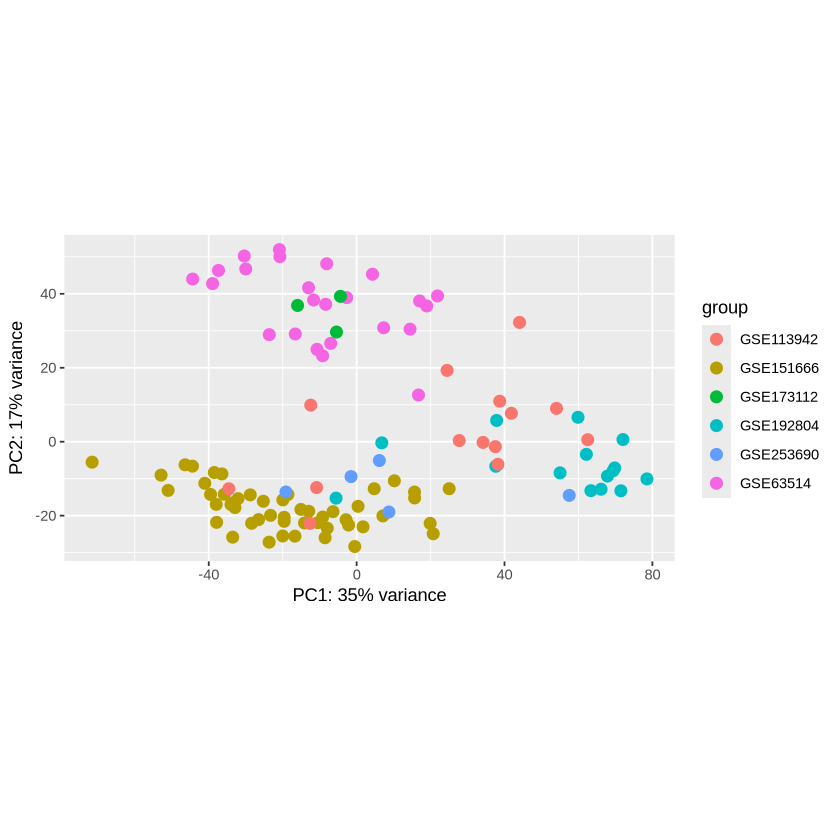

In [17]:
vsd <- vst(dds)
plotPCA(vsd, "study")

using ntop=500 top features by variance



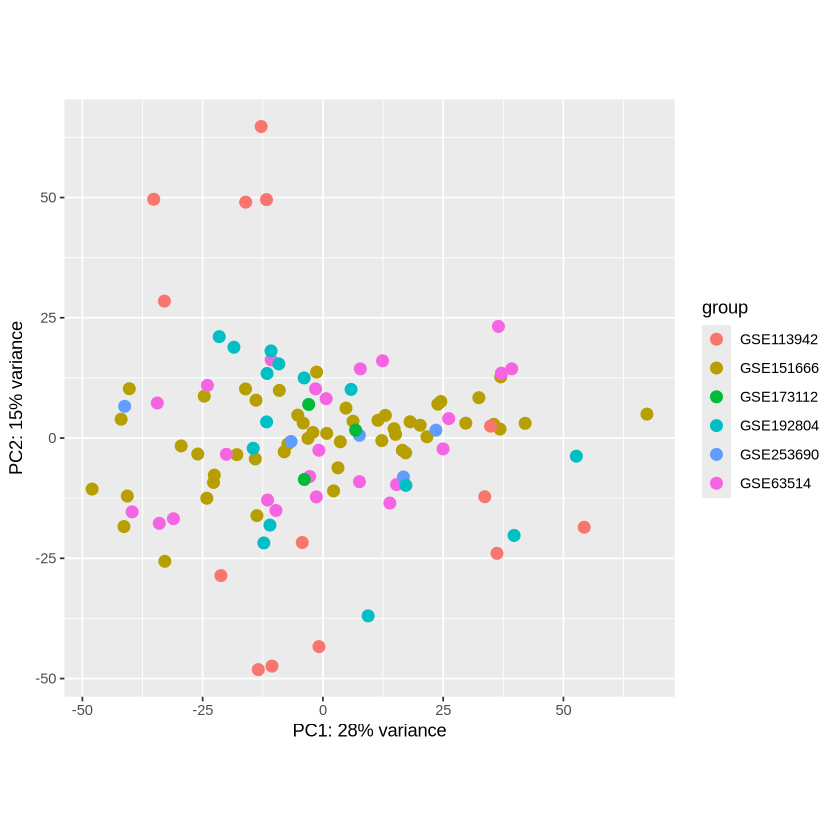

In [18]:
assay(vsd) <- limma::removeBatchEffect(assay(vsd), vsd$study)
plotPCA(vsd, "study")

using ntop=500 top features by variance



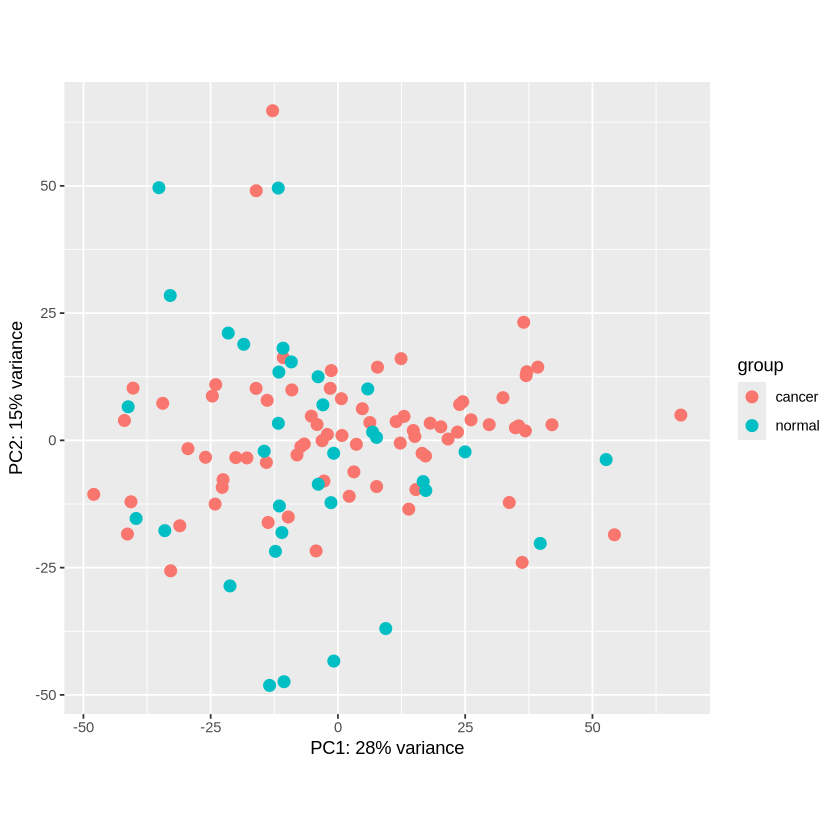

In [19]:
plotPCA(vsd, "group")

# Remove biologically related samples

In [1]:
sim_mat <- read.csv("data/112_samples/no_replicates/DESeq2_sample_similarity_matrix_pearson_111.tsv", sep="\t")
threshold <- 0.85

In [3]:
sample_list <- findCorrelation(sim_mat, cutoff = threshold)

In [4]:
sample_keep <- colnames(sim_mat)[!(colnames(sim_mat) %in% colnames(sim_mat[sample_list]))]
length(sample_keep)

[1] 41

In [9]:
viral_count <- read.csv("data/112_samples/clean_viral_counts.csv", row.names=1)
head(viral_count)

,HPV16_1,HPV18_1,HPV16_2,HPV16_3,nd_11,HPV16_4,HPV16_5,HPV58_1,HPV16_6,HPV52_1,⋯,normal_35,nd_1,nd_2,nd_3,nd_4,nd_5,nd_6,nd_7,nd_8,nd_9
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
JEMAKDHI_00004,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00008,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00010,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00012,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00014,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00016,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [10]:
write.csv(viral_count[, (sample_keep), drop=FALSE], "data/112_samples/no_replicates/raw_viral_norep.csv")

In [12]:
write.csv(design[(sample_keep), ,drop=FALSE], "data/112_samples/no_replicates/design_norep.csv")

In [13]:
write.csv(count[, (sample_keep), drop=FALSE], "data/112_samples/no_replicates/raw_human_norep.csv")

# RDSPCA

In [17]:
load("data/112_samples/deseq2.dds.RData")
ls()

[1] "count"       "dds"         "design"      "rds"         "sample_keep"
[6] "sample_list" "sim_mat"     "threshold"   "viral_count"

In [18]:
rds <- readRDS("data/112_samples/deseq2.rds")
count <- assays(rds)$counts

In [59]:
design <- read.csv("data/112_samples/design_112.csv")
head(design)

,group,sample,fastq_1,fastq_2,strandedness,study,description
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,cancer,HPV16_1,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908726.fastq.gz,,auto,GSE151666,primary_tumor
2,cancer,HPV18_1,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908727.fastq.gz,,auto,GSE151666,primary_tumor
3,cancer,HPV16_2,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908728.fastq.gz,,auto,GSE151666,primary_tumor
4,cancer,HPV16_3,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908729.fastq.gz,,auto,GSE151666,primary_tumor
5,cancer,nd_11,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908730.fastq.gz,,auto,GSE151666,primary_tumor
6,cancer,HPV16_4,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908731.fastq.gz,,auto,GSE151666,primary_tumor


In [60]:
coldata <- data.frame(row.names=design$sample, group=design$group, study=design$study)

In [61]:
countdata <- count[, rownames(coldata)]
head(countdata)

,HPV16_1,HPV18_1,HPV16_2,HPV16_3,nd_11,HPV16_4,HPV16_5,HPV58_1,HPV16_6,HPV52_1,⋯,normal_33,normal_34,normal_35,nd_1,nd_2,nd_3,nd_5,nd_7,nd_8,nd_9
A1BG,66,186,95,41,42,69,44,27,54,95,⋯,187,108,67,48,919,24,22,113,63,28
A1BG-AS1,39,46,91,32,24,35,35,23,70,59,⋯,212,189,110,25,13,6,24,79,16,13
A1CF,0,0,2,1,2,35,1,1,1,2,⋯,2,13,1,0,0,0,0,1,0,0
A2M,7522,1382,17051,2364,9357,4466,5778,5837,2560,6037,⋯,10838,17943,11406,766,123,504,4002,8879,4074,1421
A2M-AS1,14,4,67,11,95,11,4,29,16,27,⋯,136,138,92,3,1,9,4,37,9,3
A2ML1,97,3471,473,139,110,21,5108,3558,1044,379,⋯,81,371,10065,887,202,429,1637,29,7,2690


In [62]:
dds <- DESeqDataSetFromMatrix(countData=countdata, colData=coldata, design=~group)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [63]:
dds <- dds[rowSums(counts(dds)) > 0, ]
dds <- estimateSizeFactors(dds)
normalized_counts <- counts(dds,normalized=TRUE)

In [64]:
transformed <- vst(dds, blind=FALSE)

In [65]:
plotPCA_vst <- function (object,  ntop = 1000, assay=length(assays(object))) {
    rv         <- rowVars(assay(object, assay))
    select     <- order(rv, decreasing = TRUE)[seq_len(min(ntop, length(rv)))]
    pca        <- prcomp(t(assay(object, assay)[select, ]), center=TRUE, scale=FALSE)
    percentVar <- pca$sdev^2/sum(pca$sdev^2)
    df         <- cbind( as.data.frame(colData(object)), pca$x)
    ord        <- order(abs(rank(df$PC1)-median(df$PC1)), abs(rank(df$PC2)-median(df$PC2)))
    df         <- df[ord,]
    attr(df, "percentVar") <- data.frame(PC=seq(along=percentVar), percentVar=100*percentVar)
    return(df)
}

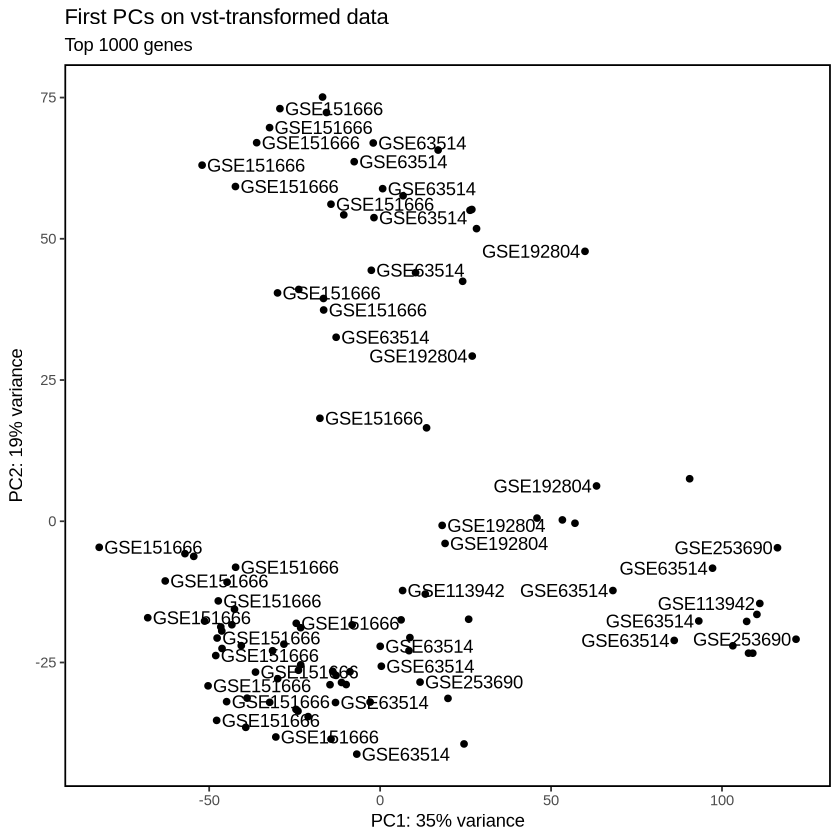

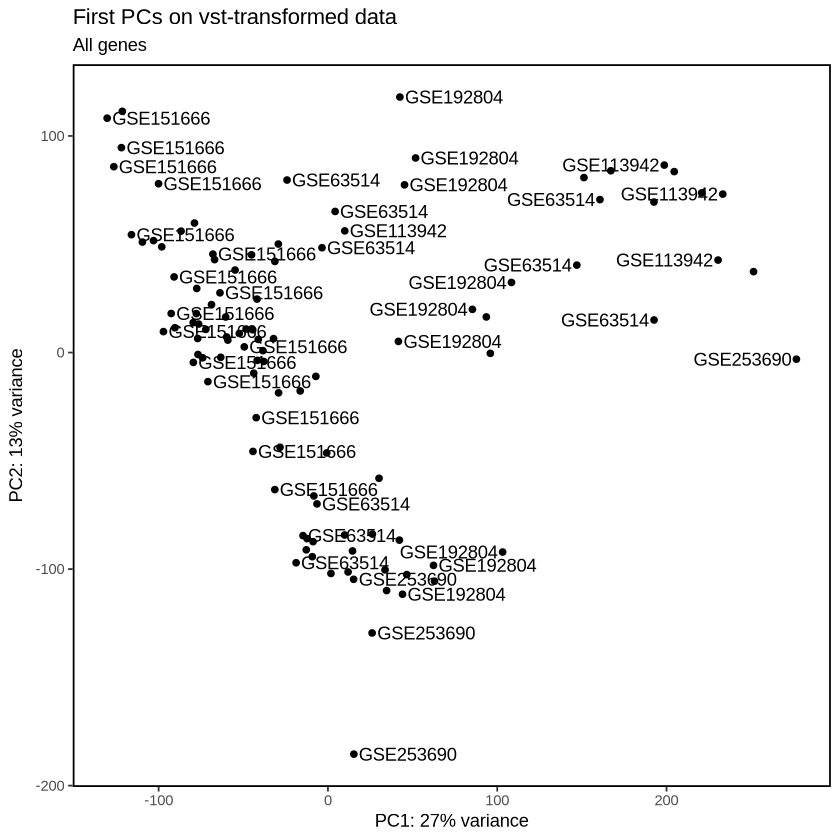

In [70]:
vst_name <- "vst"
rld      <- varianceStabilizingTransformation(dds)
assay(dds, vst_name) <- assay(rld)
vst_name <- "vst"
ntop <- c(1000, Inf)
for (n_top_var in ntop) {
    pca.data      <- plotPCA_vst(dds, assay=vst_name, ntop=n_top_var)
    percentVar    <- round(attr(pca.data, "percentVar")$percentVar)
    plot_subtitle <- ifelse(n_top_var==Inf, "All genes", paste("Top", n_top_var, "genes"))
    pl <- ggplot(pca.data, aes(PC1, PC2, label=paste0(" ", colData(transformed)$study, " "))) +
        geom_point() +
        geom_text(check_overlap=TRUE, vjust=0.5, hjust="inward") +
        xlab(paste0("PC1: ",percentVar[1],"% variance")) +
        ylab(paste0("PC2: ",percentVar[2],"% variance")) +
        labs(title = paste0("First PCs on ", vst_name, "-transformed data"), subtitle = plot_subtitle) +
        theme(legend.position="top",
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            panel.background = element_blank(),
            panel.border = element_rect(colour = "black", fill=NA, size=1))
    print(pl)
}

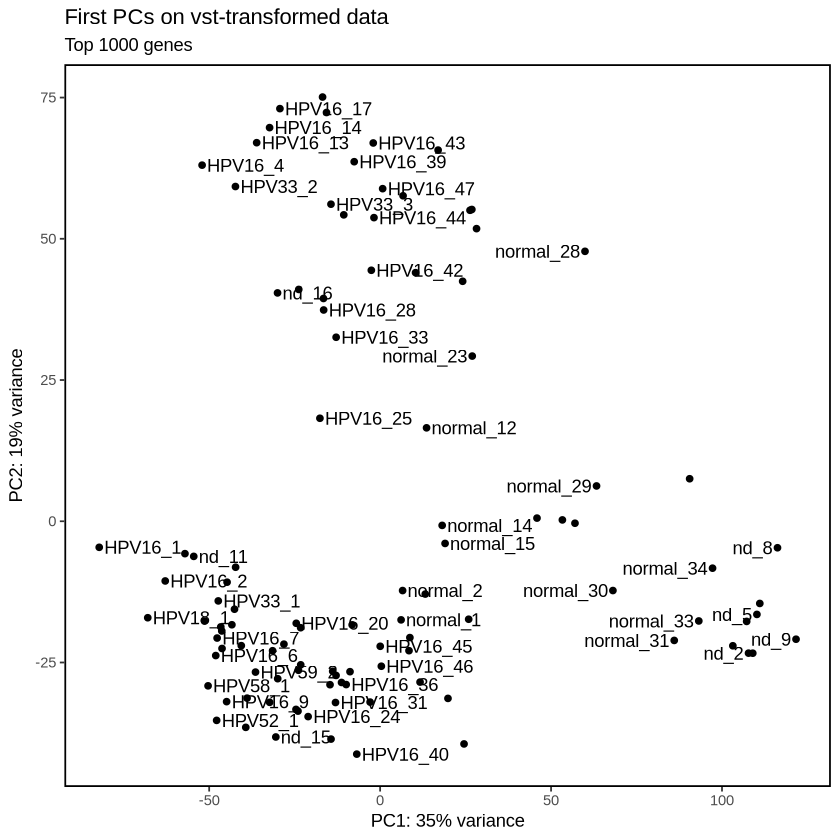

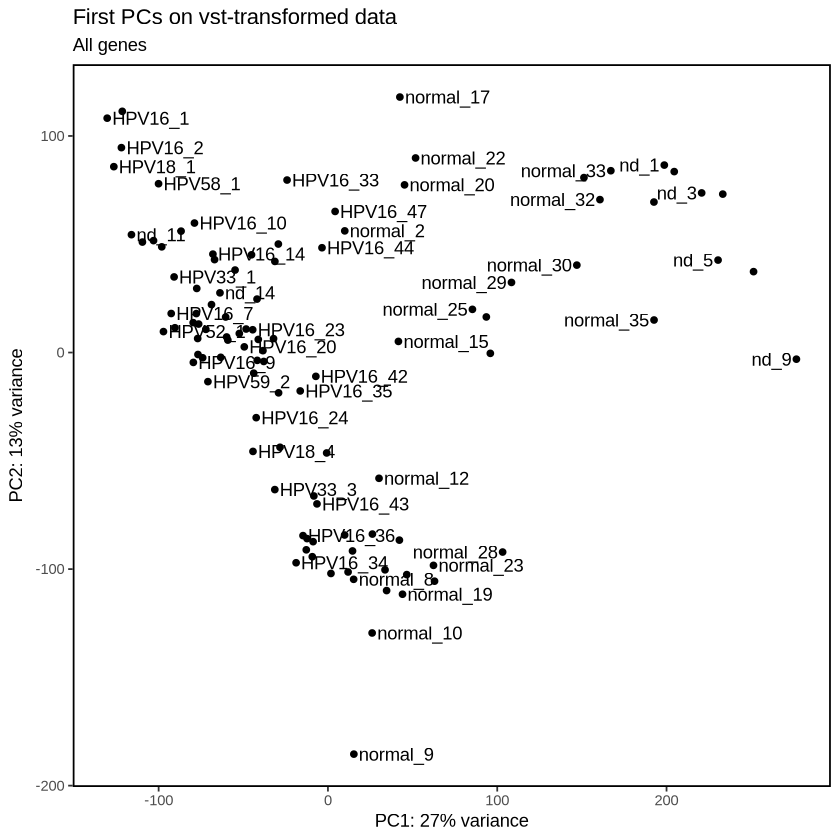

In [69]:
vst_name <- "vst"
rld      <- varianceStabilizingTransformation(dds)
assay(dds, vst_name) <- assay(rld)
vst_name <- "vst"
ntop <- c(1000, Inf)
for (n_top_var in ntop) {
    pca.data      <- plotPCA_vst(dds, assay=vst_name, ntop=n_top_var)
    percentVar    <- round(attr(pca.data, "percentVar")$percentVar)
    plot_subtitle <- ifelse(n_top_var==Inf, "All genes", paste("Top", n_top_var, "genes"))
    pl <- ggplot(pca.data, aes(PC1, PC2, label=paste0(" ", colnames(transformed), " "))) +
        geom_point() +
        geom_text(check_overlap=TRUE, vjust=0.5, hjust="inward") +
        xlab(paste0("PC1: ",percentVar[1],"% variance")) +
        ylab(paste0("PC2: ",percentVar[2],"% variance")) +
        labs(title = paste0("First PCs on ", vst_name, "-transformed data"), subtitle = plot_subtitle) +
        theme(legend.position="top",
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            panel.background = element_blank(),
            panel.border = element_rect(colour = "black", fill=NA, size=1))
    print(pl)
}